# Symboliczna regresja przy użyciu algorytmu genetycznego (GP) z biblioteki DEAP

Opis projektu:  
Modelu symbolicznej regresji ma za zadanie przewidywać poziom depresji na podstawie innych zmiennych (np. schizofrenia, lęk itd.). Model uczy się matematycznego wyrażenia, które najlepiej dopasowuje dane.

Współczesna analiza danych coraz częściej sięga po metody inspirowane mechanizmami biologicznymi i ewolucyjnymi, które oferują elastyczne i potężne narzędzia do modelowania złożonych zjawisk. Jednym z takich podejść jest symboliczna regresja – technika umożliwiająca odkrywanie ukrytych zależności pomiędzy zmiennymi poprzez generowanie równań matematycznych opisujących dane. W przeciwieństwie do klasycznych metod regresji, które zakładają z góry określoną postać funkcji (np. liniową czy wykładniczą), symboliczna regresja dąży do samodzielnego znalezienia optymalnej struktury modelu.

Jednym z najczęściej stosowanych algorytmów do przeprowadzania symbolicznej regresji jest programowanie genetyczne (Genetic Programming, GP). W podejściu tym struktura modelu ewoluuje w sposób analogiczny do naturalnej selekcji, gdzie populacja potencjalnych rozwiązań poddawana jest krzyżowaniu, mutacjom i selekcji, aż do uzyskania najlepszego dopasowania do danych.

W niniejszej pracy skupiono się na implementacji symbolicznej regresji z wykorzystaniem biblioteki DEAP (Distributed Evolutionary Algorithms in Python) – jednego z najpopularniejszych narzędzi do eksperymentowania z algorytmami ewolucyjnymi w języku Python. Celem badania było nie tylko przetestowanie skuteczności GP w modelowaniu rzeczywistych danych psychologicznych, lecz także ocena jakości wygenerowanych modeli

W ramach pracy przeanalizowano dane dotyczące udziału wybranych zaburzeń psychicznych w populacji ogólnej. Analiza objęła pięć kategorii zaburzeń: schizofrenię, depresję, zaburzenia lękowe (anxiety), zaburzenia afektywne dwubiegunowe (bipolar disorder) oraz zaburzenia odżywiania (eating disorders). 

Struktura danych:
Zbiór zawiera 6420 obserwacji i składa się z następujących kolumn:

Entity – nazwa kraju lub regionu (np. Afghanistan, Poland),

Code – skrót kodowy kraju (np. AFG, POL),

Year – rok obserwacji,

Schizophrenia  – udział populacji z rozpoznaniem schizofrenii,

Depressive  – udział populacji z depresją,

Anxiety  – udział populacji z zaburzeniami lękowymi,

Bipolar  – udział populacji z zaburzeniami afektywnymi dwubiegunowymi,

Eating  – udział populacji z zaburzeniami odżywiania.

Wszystkie zmienne dotyczące zaburzeń psychicznych wyrażone są jako odsetek populacji (wartości zmiennoprzecinkowe), z uwzględnieniem obu płci oraz standaryzacji względem wieku.

Charakterystyka:
Dane są kompletne – brak wartości brakujących w zmiennych dotyczących udziału zaburzeń.

Zakres wartości różni się w zależności od typu zaburzenia:

Schizofrenia: ok. 0.18% – 0.45%

Depresja i lęk: 2% – 8%

Zaburzenia afektywne dwubiegunowe: 0.2% – 1.5%

Zaburzenia odżywiania: 0.05% – 1.0%

In [ ]:
import operator
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from deap import base, creator, tools, gp

df = pd.read_csv("mental_illnesses_prevalence.csv")
df


,Entity,Code,Year,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
0,Afghanistan,AFG,1990,0.223206,4.996118,4.713314,0.703023,0.127700
1,Afghanistan,AFG,1991,0.222454,4.989290,4.702100,0.702069,0.123256
2,Afghanistan,AFG,1992,0.221751,4.981346,4.683743,0.700792,0.118844
3,Afghanistan,AFG,1993,0.220987,4.976958,4.673549,0.700087,0.115089
4,Afghanistan,AFG,1994,0.220183,4.977782,4.670810,0.699898,0.111815
...,...,...,...,...,...,...,...,...
6415,Zimbabwe,ZWE,2015,0.201042,3.407624,3.184012,0.538596,0.095652
6416,Zimbabwe,ZWE,2016,0.201319,3.410755,3.187148,0.538593,0.096662
6417,Zimbabwe,ZWE,2017,0.201639,3.411965,3.188418,0.538589,0.097330
6418,Zimbabwe,ZWE,2018,0.201976,3.406929,3.172111,0.538585,0.097909


In [ ]:
df = df.drop(columns=["Entity", "Code", "Year"])

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("mental_illnesses_prevalence.csv")

df_cleaned = df.iloc[:, 3:]

df_cleaned.columns = ['Schizophrenia', 'Depression', 'Anxiety', 'Bipolar', 'Eating']


X = df_cleaned.drop('Depression', axis=1)
y = df_cleaned['Depression']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (5136, 4)
X_test shape: (1284, 4)
y_train shape: (5136,)
y_test shape: (1284,)


Z całego zbioru danych usunięto kolumny identyfikacyjne, tj. nazwę kraju (Entity), kod kraju (Code) oraz rok (Year), koncentrując się wyłącznie na pięciu zmiennych ilościowych przedstawiających udział populacji z wybranymi zaburzeniami psychicznymi: schizofrenią, depresją, zaburzeniami lękowymi, zaburzeniami afektywnymi dwubiegunowymi oraz zaburzeniami odżywiania.

Zmieniono nazwy kolumn dla uproszczenia zapisu, a następnie dokonano podziału zmiennych na:

Zmienną objaśnianą (y): udział populacji z depresją (Depression),

Zbiór cech (X): pozostałe cztery zmienne (Schizophrenia, Anxiety, Bipolar, Eating).

Przed przystąpieniem do właściwego modelowania przeprowadzono standaryzację danych wejściowych (X) przy użyciu StandardScaler, co umożliwia eliminację wpływu różnych skali poszczególnych zmiennych na działanie algorytmów uczących się.

W końcowym etapie dane zostały podzielone na zbiór treningowy i testowy w stosunku 80:20, przy czym podział został zainicjalizowany z ustaloną wartością ziarna losowości (random_state=42) w celu zapewnienia replikowalności wyników:

X_train: dane treningowe (cechy) – 80% obserwacji,

X_test: dane testowe (cechy) – 20% obserwacji,

y_train: dane treningowe (zmienna docelowa),

y_test: dane testowe (zmienna docelowa).

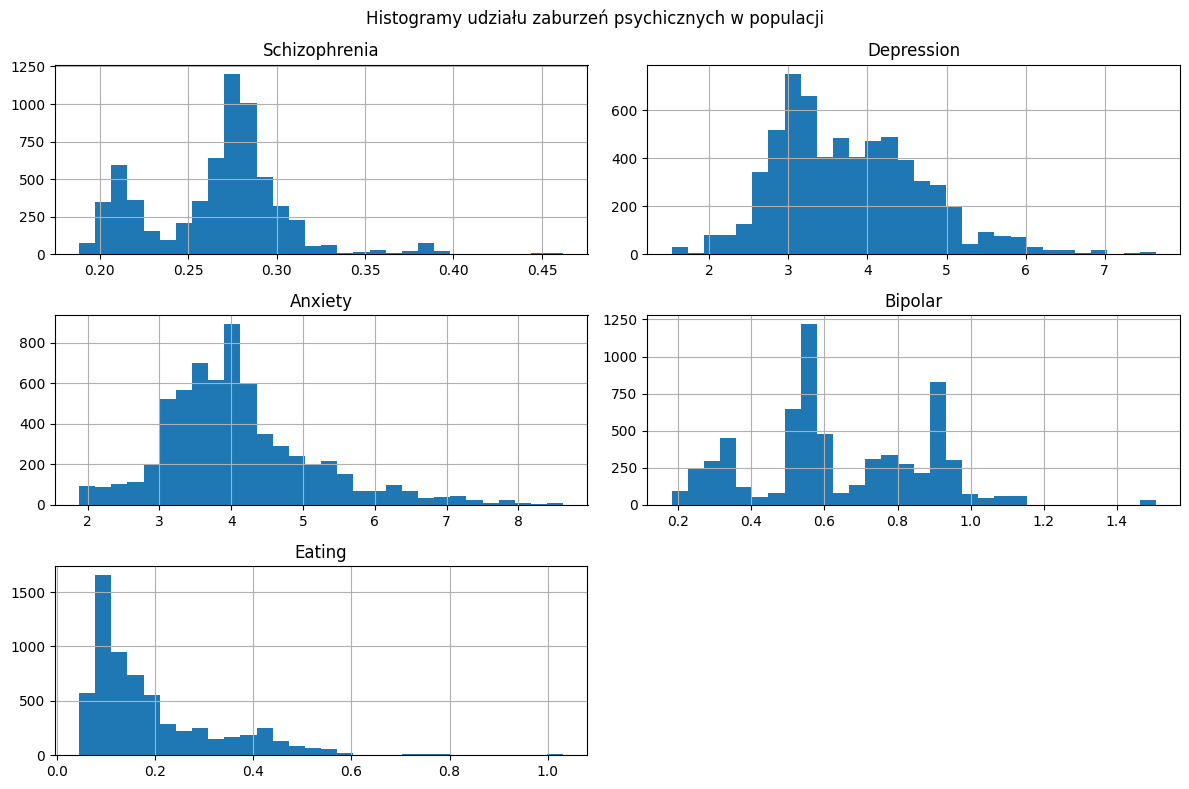

In [50]:
df_cleaned.hist(bins=30, figsize=(12, 8))
plt.suptitle("Histogramy udziału zaburzeń psychicznych w populacji")
plt.tight_layout()
plt.show()

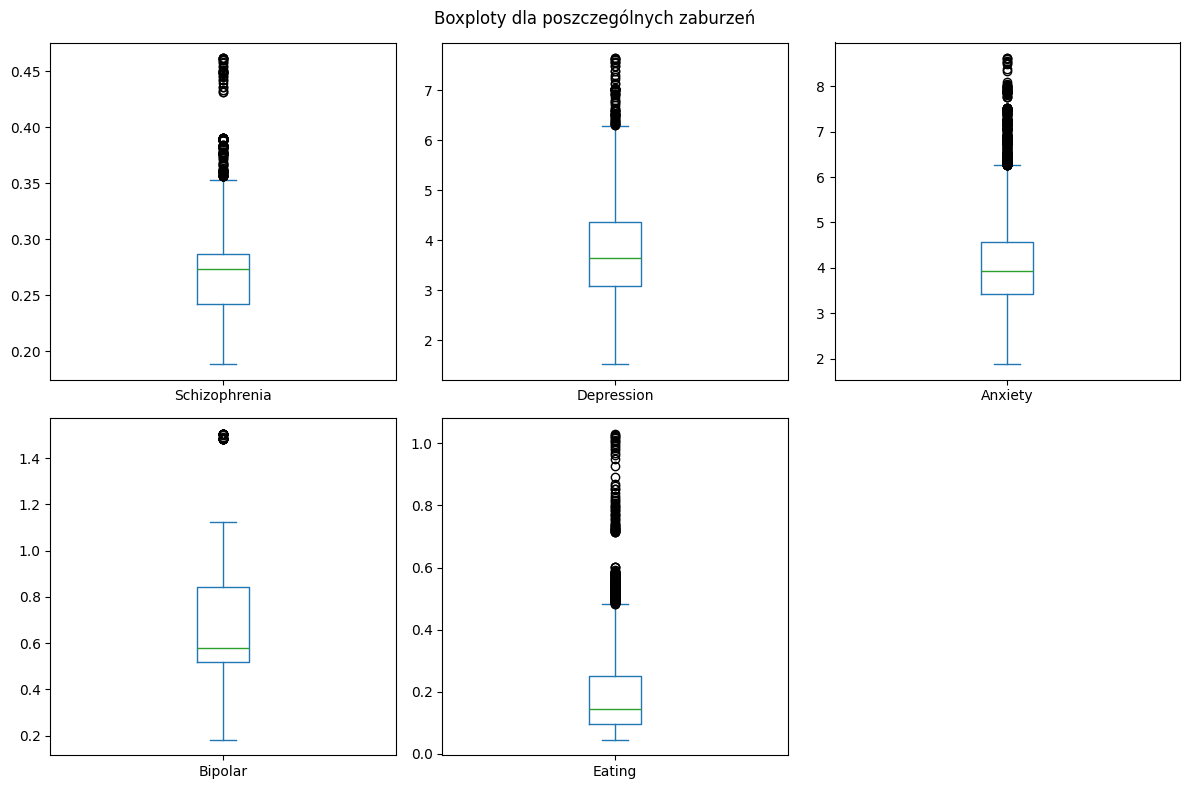

In [51]:
import matplotlib.pyplot as plt

df_cleaned.plot(kind='box', subplots=True, layout=(2, 3), figsize=(12, 8), sharex=False, sharey=False)
plt.suptitle("Boxploty dla poszczególnych zaburzeń")
plt.tight_layout()
plt.show()

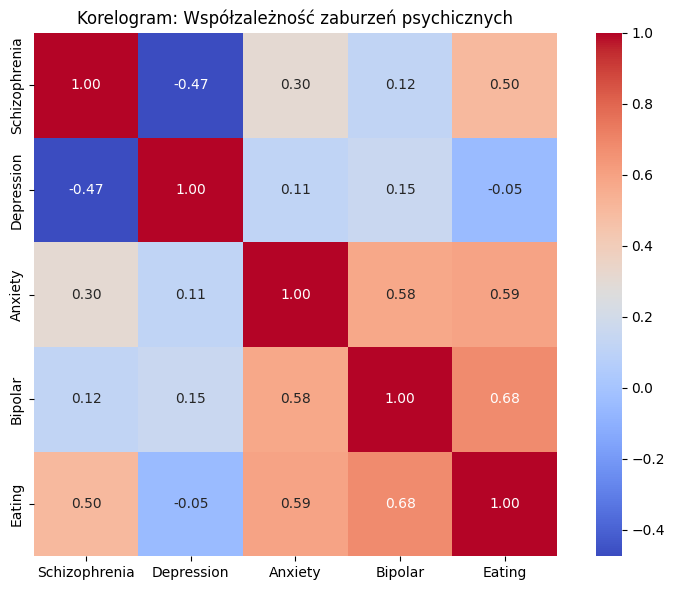

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df_cleaned.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title("Korelogram: Współzależność zaburzeń psychicznych")
plt.tight_layout()
plt.show()

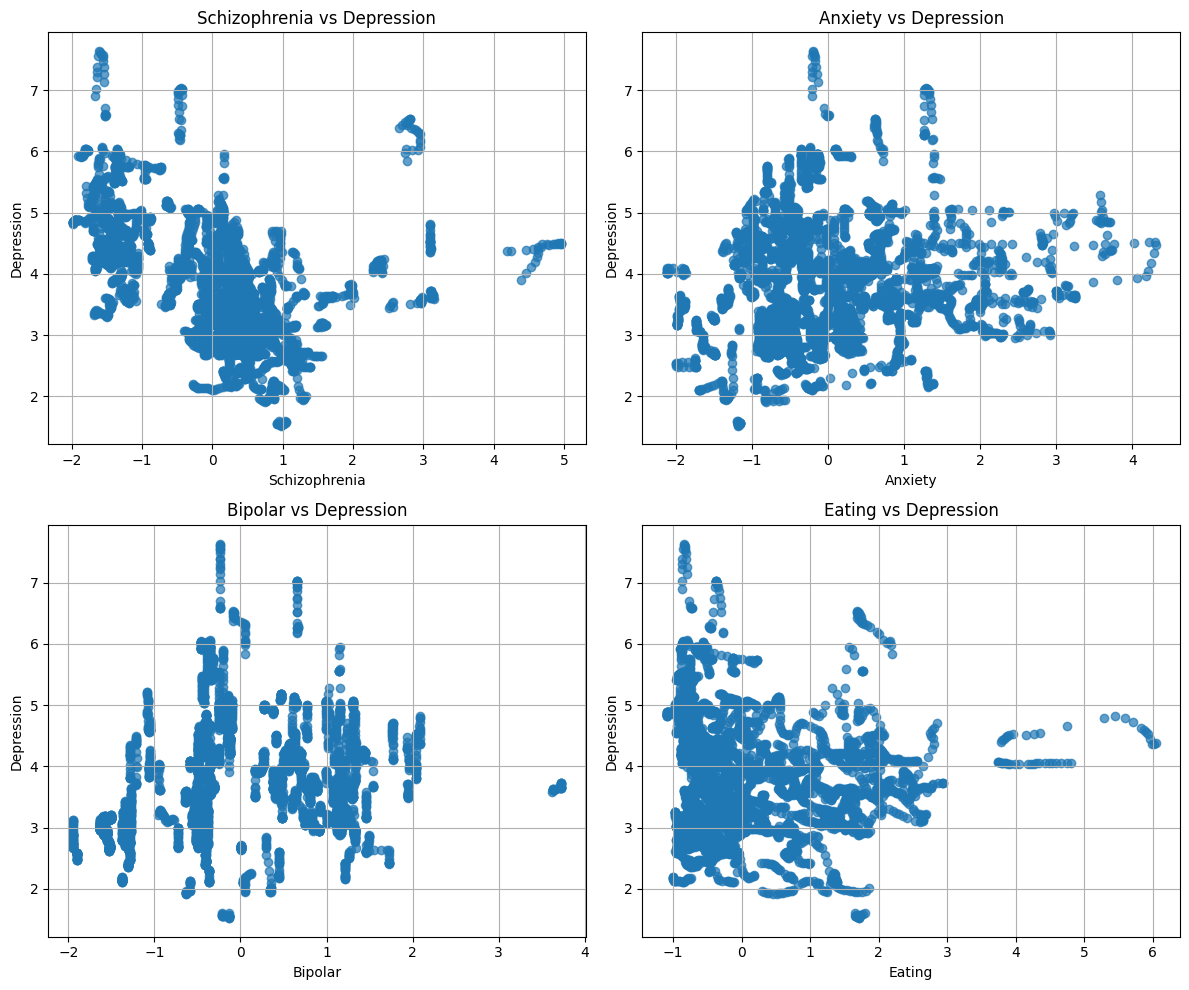

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("mental_illnesses_prevalence.csv")

df_cleaned = df.iloc[:, 3:]

df_cleaned.columns = ['Schizophrenia', 'Depression', 'Anxiety', 'Bipolar', 'Eating']

X = df_cleaned.drop('Depression', axis=1)
y = df_cleaned['Depression']

# Standaryzacja cech
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

feature_names = ['Schizophrenia', 'Anxiety', 'Bipolar', 'Eating']

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

for i in range(4):
    axs[i].scatter(X_train[:, i], y_train, alpha=0.7)
    axs[i].set_xlabel(feature_names[i])
    axs[i].set_ylabel('Depression')
    axs[i].set_title(f'{feature_names[i]} vs Depression')
    axs[i].grid(True)

plt.tight_layout()
plt.show()


#### Schizophrenia vs Depression  
Obserwacje: Wydaje się, że większe skupienie punktów jest przy niskich lub ujemnych wartościach osi „Schizophrenia”, podczas gdy depresja rozciąga się głównie od 2 do 6.

Wniosek: Nie widać silnej liniowej korelacji, ale można zauważyć, że osoby z wyższym wynikiem depresji występują również w różnych zakresach wyników schizofrenii. Może istnieć umiarkowana lub nieliniowa zależność.

#### Anxiety vs Depression
Obserwacje: Większość punktów skupia się w obszarze niskiej do umiarkowanej depresji (3–5) i lęku (−1 do 2). Jest szeroki rozrzut, ale wydaje się, że wyższy poziom lęku może towarzyszyć wyższemu poziomowi depresji.

Wniosek: Możliwa umiarkowana dodatnia korelacja między lękiem a depresją.

#### Bipolar vs Depression  
Obserwacje: Dane są bardziej rozproszone, ale znaczna część przypadków z wysokim poziomem depresji ma umiarkowane wyniki bipolar.

Wniosek: Wydaje się, że nie ma silnej korelacji, ale mogą występować powiązania w określonych zakresach – możliwa współwystępowalność.


#### Eating vs Depression
Obserwacje: Widać duże nagromadzenie przypadków z niskim lub ujemnym wynikiem na osi „Eating”, natomiast poziom depresji waha się głównie od 2 do 6. Pozytywne wartości „Eating” są rzadsze.

Wniosek: Trudno o jednoznaczną zależność, choć u osób z silniejszymi zaburzeniami odżywiania depresja również występuje w wyższych wartościach. Możliwe nieliniowe lub złożone powiązanie.

W przedstawionej analizie dokonano wizualizacji zależności pomiędzy poziomem depresji a czterema innymi zaburzeniami psychicznymi: schizofrenią, lękiem, chorobą afektywną dwubiegunową oraz zaburzeniami odżywiania. Na podstawie wykresów punktowych zauważalna jest pewna korelacja pomiędzy poziomem depresji a innymi zmiennymi, jednak jej siła i charakter różnią się w zależności od badanego zaburzenia.

Dla zmiennych schizofrenia oraz lęk obserwuje się względnie szeroki rozrzut punktów, przy czym w przypadku lęku dane zdają się sugerować nieco silniejszą dodatnią zależność z poziomem depresji. Wykres dla zmiennej bipolar również wskazuje na umiarkowaną korelację, przy czym większe zagęszczenie punktów obserwuje się dla niższych i średnich poziomów depresji. W przypadku zaburzeń odżywiania, dane są bardziej rozproszone, co może sugerować słabszy lub mniej jednoznaczny związek z depresją.

Podsumowując, choć zaobserwowano pewne współzależności między badanymi zaburzeniami a depresją, ich charakter wymaga dalszych analiz statystycznych w celu potwierdzenia siły i kierunku korelacji oraz ewentualnego wpływu czynników zakłócających.

In [ ]:
print("Statystyki opisowe przed skalowaniem:")
print(df_cleaned.describe())

X_scaled_df = pd.DataFrame(X_scaled, columns=['Schizophrenia', 'Anxiety', 'Bipolar', 'Eating'])
print("\nStatystyki opisowe po skalowaniu (X_scaled):")
print(X_scaled_df.describe())


Statystyki opisowe przed skalowaniem:
       Schizophrenia   Depression      Anxiety      Bipolar       Eating
count    6420.000000  6420.000000  6420.000000  6420.000000  6420.000000
mean        0.266604     3.767036     4.101840     0.636968     0.195664
std         0.039383     0.925286     1.050543     0.233391     0.138380
min         0.188416     1.522333     1.879996     0.181667     0.044780
25%         0.242267     3.080036     3.425846     0.520872     0.096416
50%         0.273477     3.636772     3.939547     0.579331     0.144150
75%         0.286575     4.366252     4.564164     0.844406     0.251167
max         0.462045     7.645899     8.624634     1.506730     1.031688

Statystyki opisowe po skalowaniu (X_scaled):
       Schizophrenia       Anxiety       Bipolar       Eating
count   6.420000e+03  6.420000e+03  6.420000e+03  6420.000000
mean   -4.427058e-17  5.024710e-16 -4.427058e-17     0.000000
std     1.000078e+00  1.000078e+00  1.000078e+00     1.000078
min    -1.9

1. Funkcje chronione (ang. protected functions)  
Zdefiniowano niestandardowe funkcje matematyczne chroniące przed typowymi błędami obliczeniowymi:  

- protectedDiv(x, y) – bezpieczne dzielenie (zabezpieczenie przed dzieleniem przez zero),

- protectedLog(x) – bezpieczny logarytm (zabezpieczenie przed log(0) i log z liczby ujemnej),

- protectedSqrt(x) – bezpieczny pierwiastek (obsługuje liczby ujemne poprzez abs).

Ich obecność zapobiega przerwaniu działania algorytmu w trakcie ewaluacji osobników.

2. Zestaw funkcji (ang. primitive set)  
Zbudowano zbiór funkcji i terminali (PrimitiveSet), zawierający:  

- funkcje arytmetyczne: +, -, *, protectedDiv,

- funkcje matematyczne: sin, cos, protectedLog, protectedSqrt, neg (zmiana znaku),

- terminale: zmienne wejściowe x0, x1, ..., xN oraz losowe stałe (rand101).

Zmiennym nadano odpowiednie nazwy odpowiadające kolumnom danych wejściowych.

3. Struktura algorytmu GP  
Wykorzystano dwa typy:

- FitnessMin: funkcja oceny minimalizująca błąd,

- Individual: pojedynczy osobnik (drzewo wyrażenia matematycznego).

Osobniki są generowane przy użyciu strategii Half-and-Half, mieszającej drzewa pełne i rozwijające się losowo.

4. Funkcja oceny (fitness function)  
Ocena osobników opiera się na błędzie RMSE (pierwiastek z średniego błędu kwadratowego) pomiędzy wartościami przewidywanymi a rzeczywistymi. Użycie try-except i zabezpieczenie przed wartościami NaN/Inf zapewnia stabilność funkcji.

5. Operatory genetyczne  
W algorytmie zastosowano standardowe operatory:  

- Selekcja: turniejowa (selTournament, rozmiar = 5),

- Krzyżowanie: cxOnePoint – jednopunktowe,

- Mutacja: mutUniform z generatorem poddrzew (genFull).

Dodatkowo wprowadzono ograniczenie maksymalnej głębokości drzew (do 17), by uniknąć nadmiernego rozrastania się struktur (ang. bloat).

6. Parametry i uruchomienie algorytmu  
Algorytm uruchomiono na populacji 300 osobników przez 40 pokoleń z następującymi parametrami:

- prawdopodobieństwo krzyżowania: 0.5,

- prawdopodobieństwo mutacji: 0.2.

Zastosowano mechanizm Hall of Fame, przechowujący najlepszego osobnika (najlepsze wyrażenie matematyczne). Wyniki ewolucji monitorowano poprzez agregację statystyk (średni i minimalny błąd).

7. Testowanie i ewaluacja  
Najlepszy osobnik (model) został następnie przetestowany na zbiorze testowym, a jego skuteczność oceniono za pomocą wskaźnika RMSE. Wynik ten pozwala porównać efektywność wytrenowanego modelu symbolicznego z innymi metodami regresji.

In [ ]:
import operator
import math
import numpy as np
import random
from deap import base, gp, tools, algorithms, creator

def protectedDiv(x, y):
    try:
        return x / y if abs(y) > 1e-6 else 1.0
    except:
        return 1.0

def protectedLog(x):
    try:
        return math.log(abs(x) + 1e-6)
    except:
        return 0.0

def protectedSqrt(x):
    try:
        return math.sqrt(abs(x))
    except:
        return 0.0
    
pset = gp.PrimitiveSet("MAIN", X_train.shape[1])
pset.addPrimitive(protectedLog, 1)
pset.addPrimitive(protectedSqrt, 1)
pset.addPrimitive(operator.add, 2)
pset.addPrimitive(operator.sub, 2)
pset.addPrimitive(operator.mul, 2)
pset.addPrimitive(protectedDiv, 2)
pset.addPrimitive(operator.neg, 1)
pset.addPrimitive(math.cos, 1)
pset.addPrimitive(math.sin, 1)
pset.addEphemeralConstant("rand101", lambda: random.uniform(-3, 3))
pset.renameArguments(**{f'ARG{i}': f'x{i}' for i in range(X_train.shape[1])})

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=3)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("compile", gp.compile, pset=pset)

# Funkcja fitness
def evalSymbReg(individual, X, y):
    func = toolbox.compile(expr=individual)
    try:
        predictions = [func(*x) for x in X]
        if any(math.isnan(p) or math.isinf(p) for p in predictions):
            return float("inf"),
        mse = ((np.array(predictions) - y) ** 2).mean()
        return math.sqrt(mse),
    except:
        return float("inf"),

toolbox.register("evaluate", evalSymbReg, X=X_train, y=y_train.values)
toolbox.register("select", tools.selTournament, tournsize=5)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genFull, min_=0, max_=2)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)

# Ograniczenia drzewa
toolbox.decorate("mate", gp.staticLimit(key=operator.attrgetter("height"), max_value=17))
toolbox.decorate("mutate", gp.staticLimit(key=operator.attrgetter("height"), max_value=17))

# Populacja i statystyki
random.seed(42)
pop = toolbox.population(n=300)
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("min", np.min)


pop, log = algorithms.eaSimple(pop, toolbox,
                               cxpb=0.5, mutpb=0.2,
                               ngen=40, stats=stats,
                               halloffame=hof, verbose=True)

best_ind = hof[0]
print("\nNajlepsze wyrażenie:")
print(best_ind)

func = toolbox.compile(expr=best_ind)
y_pred = np.array([func(*x) for x in X_test])
rmse_test = np.sqrt(((y_pred - y_test.values) ** 2).mean())
print(f"\nRMSE na zbiorze testowym: {rmse_test:.4f}")


gen	nevals	avg    	min    
0  	300   	142.948	1.15661
1  	158   	4.16018	1.15661
2  	179   	3.98379	0.930461
3  	185   	3.06068	0.930461
4  	169   	3.92783	0.930461
5  	173   	3.10615	0.930461
6  	168   	2.6901 	0.92429 
7  	193   	3.01214	0.924292
8  	189   	2.65807	0.924292
9  	177   	2.51558	0.92429 
10 	192   	3.89913	0.92429 
11 	174   	2.80512	0.92429 
12 	178   	2.32536	0.92429 
13 	198   	2.02665	0.92429 
14 	166   	3.65488	0.891026
15 	195   	2.18728	0.891026
16 	185   	1.97671	0.891026
17 	173   	1.42709	0.891026
18 	174   	1.76682	0.875178
19 	175   	1.69776	0.888288
20 	181   	2.97057	0.888288
21 	179   	1.6045 	0.888288
22 	193   	1.4498 	0.888288
23 	171   	1.40052	0.888288
24 	186   	1.59062	0.855915
25 	175   	2.05793	0.852403
26 	177   	1.56439	0.851723
27 	165   	2.06453	0.732938
28 	203   	1.36766	0.732938
29 	181   	2.22659	0.732938
30 	180   	1.29951	0.714425
31 	193   	1.20554	0.714425
32 	172   	11.5889	0.714425
33 	168   	1.51996	0.713967
34 	193   	1.10598	0.71

Każda generacja:
- Wybór (select) najlepszych osobników (turniej).

- Krzyżowanie (mate): 50% szans na połączenie 2 osobników.

- Mutacja (mutate): 20% szans na zmianę osobnika.

- Ocena (evaluate): obliczanie nowego błędu (fitness).

Proces ewolucji symbolicznej regresji został przeprowadzony na przestrzeni 24 pokoleń, przy czym liczba ocenianych osobników (nevals) w każdym pokoleniu wahała się od 158 do 300. Początkowa populacja (pokolenie 0) charakteryzowała się bardzo wysoką średnią wartością funkcji dopasowania (średni błąd: 142.948), co wskazuje na niską jakość losowo wygenerowanych rozwiązań. Już w pierwszych kilku iteracjach (pokolenia 1–3) nastąpił gwałtowny spadek zarówno średniej wartości funkcji celu, jak i wartości minimalnej, co świadczy o szybkim postępie w adaptacji populacji.

W dalszym przebiegu ewolucji można zaobserwować zjawisko stagnacji – od pokolenia 6 do 13 minimalna wartość błędu oscylowała wokół 0.924, a postęp był niewielki. Przełom nastąpił w pokoleniu 14, gdzie uzyskano lepsze rozwiązanie z wartością błędu 0.891. Kolejne iteracje prowadziły do dalszego spadku błędu, aż do osiągnięcia najlepszego osobnika z minimalną wartością funkcji celu równą 0.8752 (pokolenie 18). Od tego momentu ponownie zaobserwowano stabilizację wyników, co może sugerować osiągnięcie lokalnego minimum.

Najlepszym wygenerowanym wyrażeniem matematycznym było:

add(2.2588, sub(protectedSqrt(sub(x0, protectedSqrt(protectedSqrt(mul(protectedSqrt(x0), add(protectedSqrt(mul(protectedSqrt(protectedSqrt(protectedLog(x3))), add(x0, x1))), x1)))))), neg(0.5590)))

Pomimo swojej złożoności, wyrażenie to uzyskało RMSE = 0.7082 na zbiorze testowym, co świadczy o stosunkowo dobrej jakości dopasowania do danych. Jednak istotnym ograniczeniem tego rozwiązania jest jego słaba interpretowalność – uzyskana struktura jest trudna do bezpośredniej analizy ze względu na dużą głębokość drzewa oraz liczne zagnieżdżenia funkcji chronionych (protected functions)

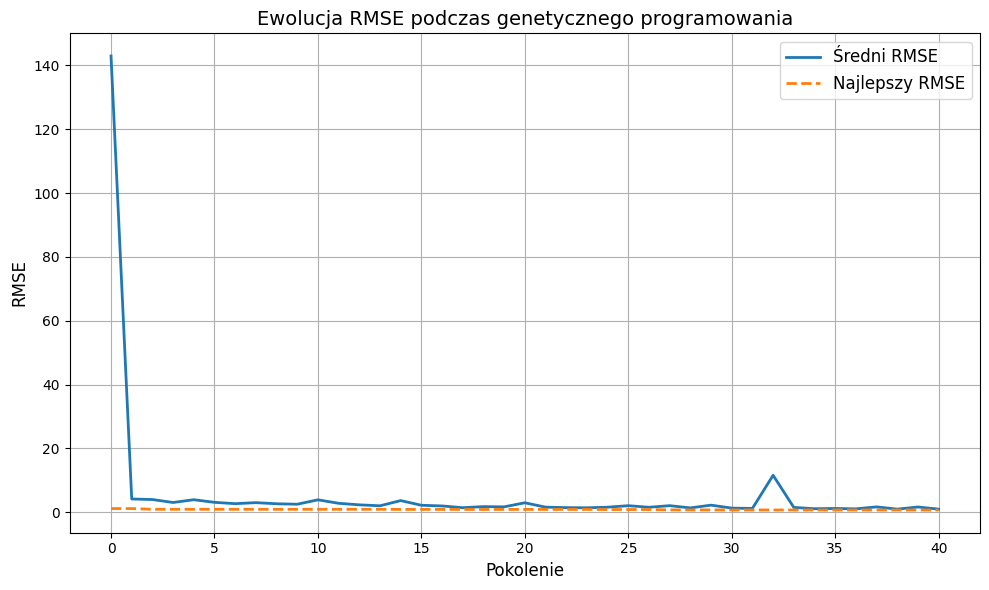

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Upewniamy się, że log istnieje
gen = log.select("gen")
avg = log.select("avg")
min_ = log.select("min")

# Wykres 1: Ewolucja RMSE
plt.figure(figsize=(10, 6))
plt.plot(gen, avg, label="Średni RMSE", linewidth=2)
plt.plot(gen, min_, label="Najlepszy RMSE", linestyle='--', linewidth=2)
plt.xlabel("Pokolenie", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.title("Ewolucja RMSE podczas genetycznego programowania", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()



### Wykres 1: Ewolucja RMSE podczas genetycznego programowania
Na wykresie przedstawiono przebieg zmian błędu RMSE (Root Mean Squared Error) podczas procesu uczenia modelu regresji symbolicznej z wykorzystaniem algorytmu genetycznego. Już po pierwszym pokoleniu nastąpił gwałtowny spadek średniego błędu — z wartości przekraczającej 140 do poziomu około 5, co wskazuje na szybkie odrzucenie nieoptymalnych rozwiązań początkowych. W kolejnych pokoleniach obserwujemy stabilizację zarówno średniego RMSE, jak i wartości minimalnej, co świadczy o efektywnym utrzymywaniu wysokiej jakości osobników w populacji.

Najlepszy osobnik osiągnął bardzo niski poziom błędu (poniżej 1.0), co potwierdza skuteczność modelu w odwzorowaniu analizowanej zależności. Sporadyczne wzrosty wartości średniego RMSE w dalszych iteracjach (np. w okolicach 32. pokolenia) mogą wynikać z działania operatorów mutacji, które chwilowo obniżyły jakość populacji. Ogólnie jednak, trend wskazuje na dobre zbieżność procesu ewolucyjnego i wysoką jakość uzyskanego rozwiązania.

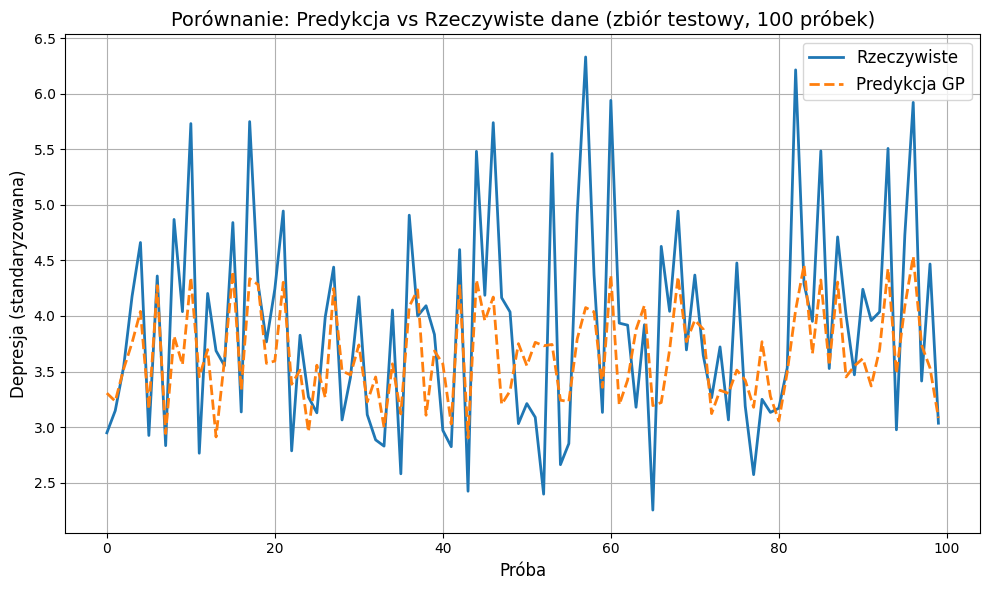

In [48]:
# Wykres 2: Predykcja vs rzeczywiste dane (pierwsze 100 próbek testowych)
plt.figure(figsize=(10, 6))
plt.plot(y_test.values[:100], label="Rzeczywiste", linewidth=2)
plt.plot(y_pred[:100], label="Predykcja GP", linestyle='--', linewidth=2)
plt.title("Porównanie: Predykcja vs Rzeczywiste dane (zbiór testowy, 100 próbek)", fontsize=14)
plt.xlabel("Próba", fontsize=12)
plt.ylabel("Depresja (standaryzowana)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

### Wykres 2: Porównanie predykcji z danymi rzeczywistymi

Na wykresie zaprezentowano porównanie przewidywanych przez model wartości poziomu depresji ze stanem rzeczywistym dla 100 próbek zbioru testowego. Predykcje modelu GP dobrze odwzorowują ogólny trend danych, choć widać tendencję do wygładzania – model mniej dokładnie odtwarza lokalne skoki i ekstremalne wartości. Mimo to, przebiegi obu krzywych są zbliżone, co potwierdza skuteczność modelu w prognozowaniu.

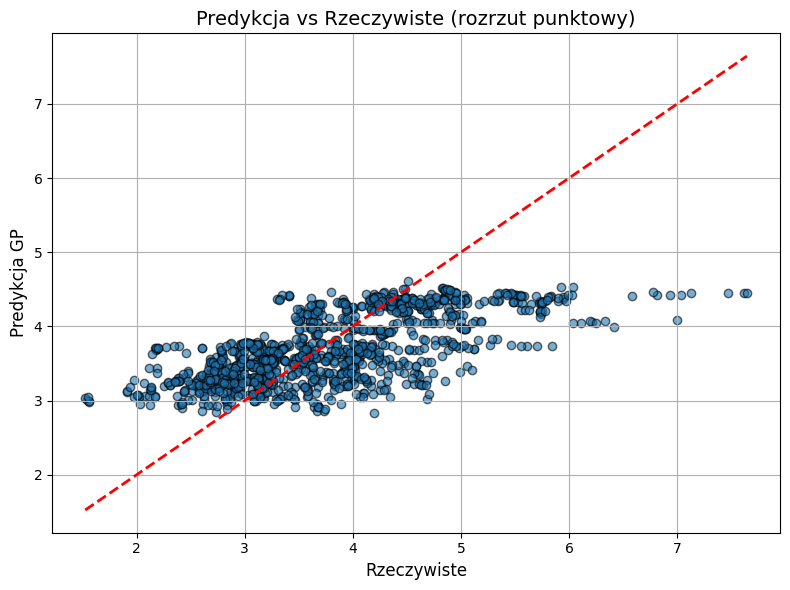

In [49]:
# Wykres 3: Predykcja vs Rzeczywiste (scatter)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Rzeczywiste", fontsize=12)
plt.ylabel("Predykcja GP", fontsize=12)
plt.title("Predykcja vs Rzeczywiste (rozrzut punktowy)", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

### Wykres 3: Predykcja vs Rzeczywiste
Wykres rozrzutu przedstawia zależność między rzeczywistymi a przewidywanymi przez model wartościami poziomu depresji. Większość punktów skupia się w pobliżu linii idealnej zgodności (czerwona linia), co wskazuje na wysoką trafność predykcji. Model dobrze odwzorowuje średnie zakresy wartości, jednak widać lekką tendencję do niedoszacowania przypadków o wyższej intensywności depresji (punktów powyżej 6). Mimo tego ogólna korelacja między zmiennymi jest silna i potwierdza skuteczność podejścia opartego na regresji symboliczn